# Machine Intelligence II
### Principal Component Analysis
##### Group members: Nikita Bauer, Anastasija Markovska, Ibrahim Ulas Ayyilmaz, Rezwana Hussainzada
---
**Exercise H1.1: PCA: 2-dimensional Toy Data**

*(a)* Load the dataset pca-data-2d.dat and create a scatter plot of the centered data.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

(10, 2)
Data mean: [ 1.91 -1.81]
Centered data mean: [3.55271368e-16 4.44089210e-17]


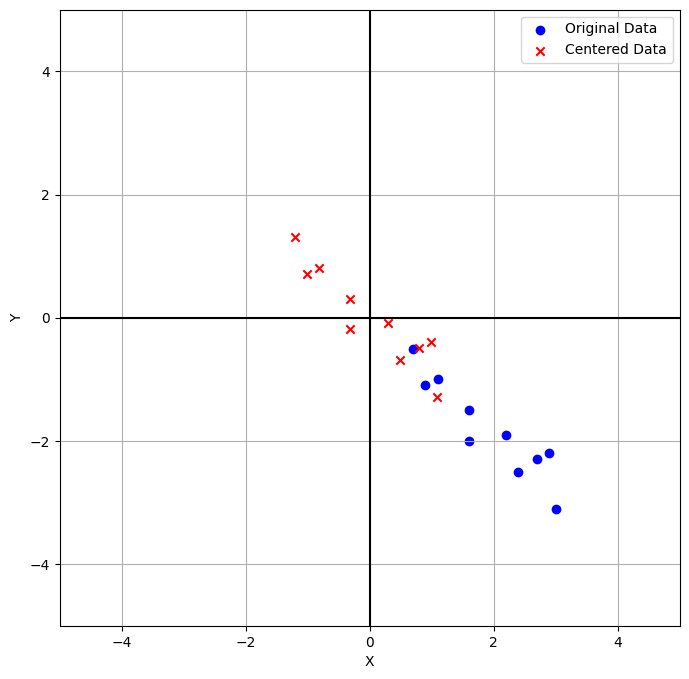

In [ ]:
path = "/content/drive/MyDrive/MI2/Sheet01/pca-data-2d.dat.txt"
data_1 = np.loadtxt(path)
print(data_1.shape)

data_1_mean =  np.mean(data_1, axis=0)
print(f"Data mean: {data_1_mean}")

centered_data = data_1 - data_1_mean
centered_data_mean = np.mean(centered_data, axis=0)
print(f"Centered data mean: {centered_data_mean}")

plt.figure(figsize=(8,8))
plt.scatter(data_1[:,0], data_1[:,1], color='blue', marker='o', label='Original Data')
plt.scatter(centered_data[:,0], centered_data[:,1], color='red', marker='x', label='Centered Data')
plt.plot([-5, 5], [0, 0], color='black')
plt.plot([0, 0], [-5, 5], color='black')

plt.xlim(-5,5)
plt.ylim(-5, 5)
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid()
plt.show()




*(b)* Determine the Principal Components (PCs) and create another scatter plot of the same data points in the coordinate system spanned by the 2 PCs.


Eigenvalues: [1.28402771 0.0490834 ]
PC1: [ 0.73517866 -0.6778734 ]
PC2: [0.6778734  0.73517866]


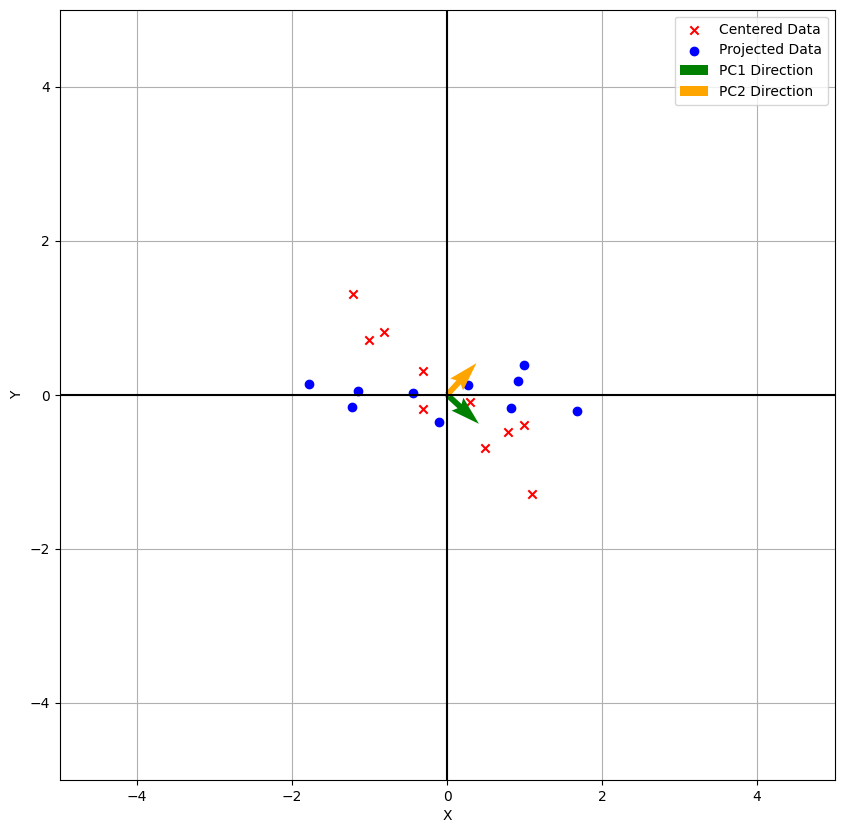

In [ ]:
cov_matrix_1 = np.cov(centered_data.T)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix_1)
print(f"Eigenvalues: {eigenvalues}")

pca_1 = eigenvectors[:,0]
pca_2 = eigenvectors[:,1]
print(f"PC1: {pca_1}")
print(f"PC2: {pca_2}")

projected_data = np.dot(centered_data, eigenvectors)


plt.figure(figsize=(10,10))

plt.scatter(centered_data[:,0], centered_data[:,1], color='red', marker='x', label='Centered Data')
plt.scatter(projected_data[:,0], projected_data[:,1], color='blue', marker='o', label='Projected Data')

plt.quiver(0, 0, eigenvectors[0, 0], eigenvectors[1, 0], color='green', angles='xy', scale_units='xy', label='PC1 Direction')
plt.quiver(0, 0, eigenvectors[0, 1], eigenvectors[1, 1], color='orange', angles='xy', scale_units='xy', label='PC2 Direction')
plt.plot([-5, 5], [0, 0], color='black')
plt.plot([0, 0], [-5, 5], color='black')


plt.xlim(-5,5)
plt.ylim(-5, 5)
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid()
plt.show()


*(c)* PCA can be used to compress data e.g. using only information contained in the first M out of N PCs. Plot the reconstruction of the data in the original coordinate system when using (i) only the first or (ii) only the second PC for reconstruction.


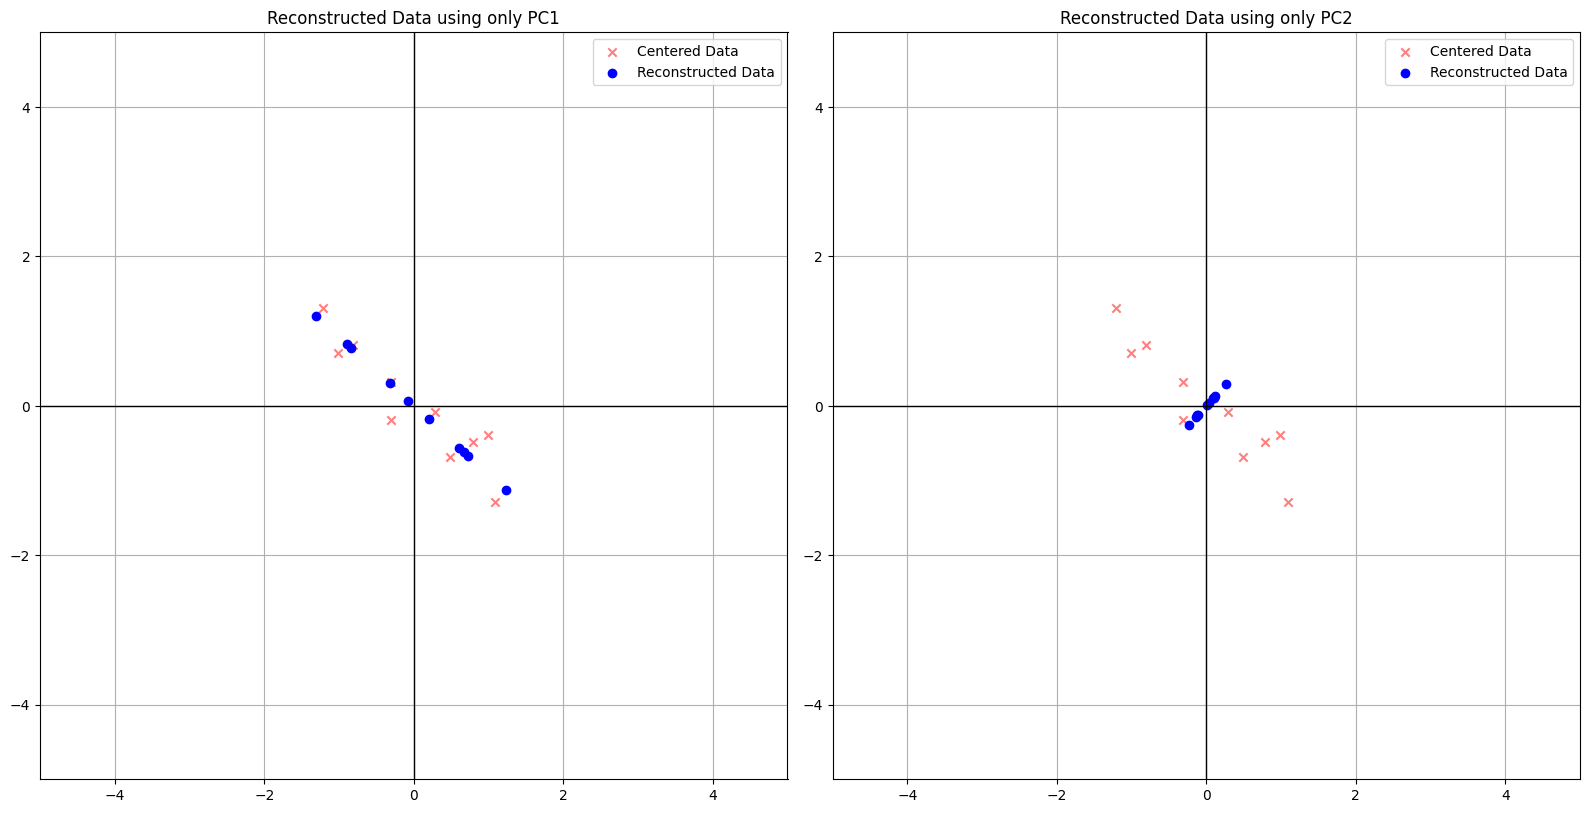

In [ ]:
recon_pc1_only = projected_data.copy()
recon_pc2_only = projected_data.copy()

recon_pc1_only[:, 1] = 0
recon_pc2_only[:, 0] = 0

data_reconstructed_1 = recon_pc1_only @ eigenvectors.T
data_reconstructed_2 = recon_pc2_only @ eigenvectors.T


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

ax1.scatter(centered_data[:, 0], centered_data[:, 1], color='red', marker='x', alpha=0.5, label='Centered Data')
ax1.scatter(data_reconstructed_1[:, 0], data_reconstructed_1[:, 1], color='blue', marker='o', label='Reconstructed Data')
ax1.set_title('Reconstructed Data using only PC1')
ax1.legend()
ax1.grid(True)
ax1.axhline(0, color='black', linewidth=1)
ax1.axvline(0, color='black', linewidth=1)
ax1.set_xlim(-5, 5)
ax1.set_ylim(-5, 5)
ax1.set_aspect('equal')

ax2.scatter(centered_data[:, 0], centered_data[:, 1], color='red', marker='x', alpha=0.5, label='Centered Data')
ax2.scatter(data_reconstructed_2[:, 0], data_reconstructed_2[:, 1], color='blue', marker='o', label='Reconstructed Data')
ax2.set_title('Reconstructed Data using only PC2')
ax2.legend()
ax2.grid(True)
ax2.axhline(0, color='black', linewidth=1)
ax2.axvline(0, color='black', linewidth=1)
ax2.set_xlim(-5, 5)
ax2.set_ylim(-5, 5)
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()



**Exercise H1.2: PCA: 3-dimensional Toy Data**

*(a)* Load the dataset pca-data-3d.txt, center it, and show the scatter plot matrix.

(500, 3)
Data mean: [ 0.04355465  0.09190794 -0.0594604 ]


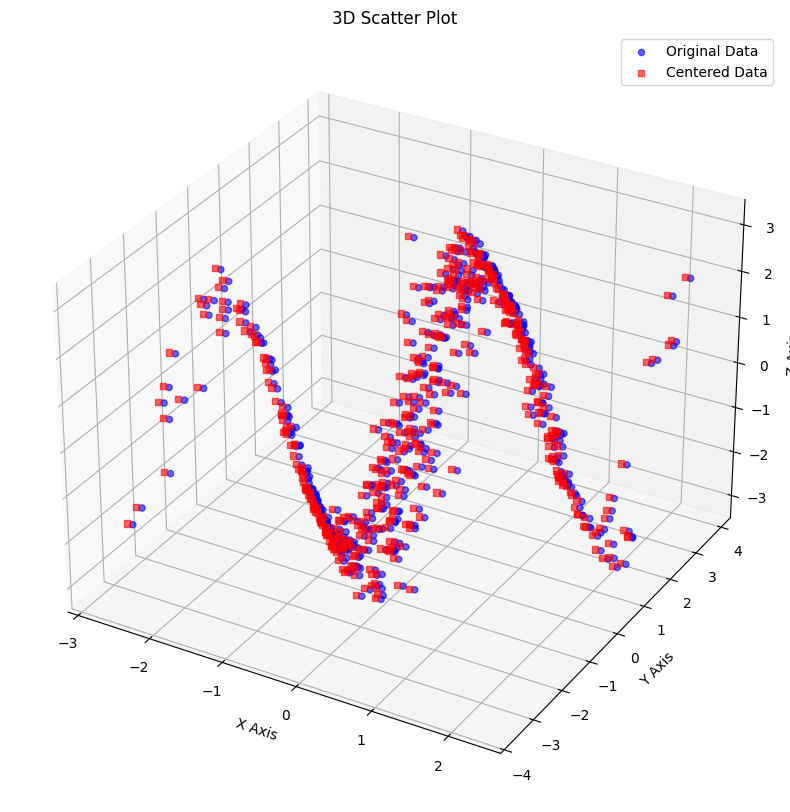

In [ ]:
path = "/content/drive/MyDrive/MI2/Sheet01/pca-data-3d.txt"
data_2 = pd.read_csv(path).to_numpy()
print(data_2.shape)

data_2_mean = np.mean(data_2, axis=0)
print(f"Data mean: {data_2_mean}")

centered_data_2 = data_2 - data_2_mean

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')


ax.scatter(data_2[:, 0], data_2[:, 1], data_2[:, 2], c='blue', marker='o', alpha=0.6, label='Original Data')
ax.scatter(centered_data_2[:, 0], centered_data_2[:, 1], centered_data_2[:, 2], c='red', marker='s', alpha=0.6, label='Centered Data')



ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')
ax.set_title('3D Scatter Plot')

ax.legend()
plt.show()

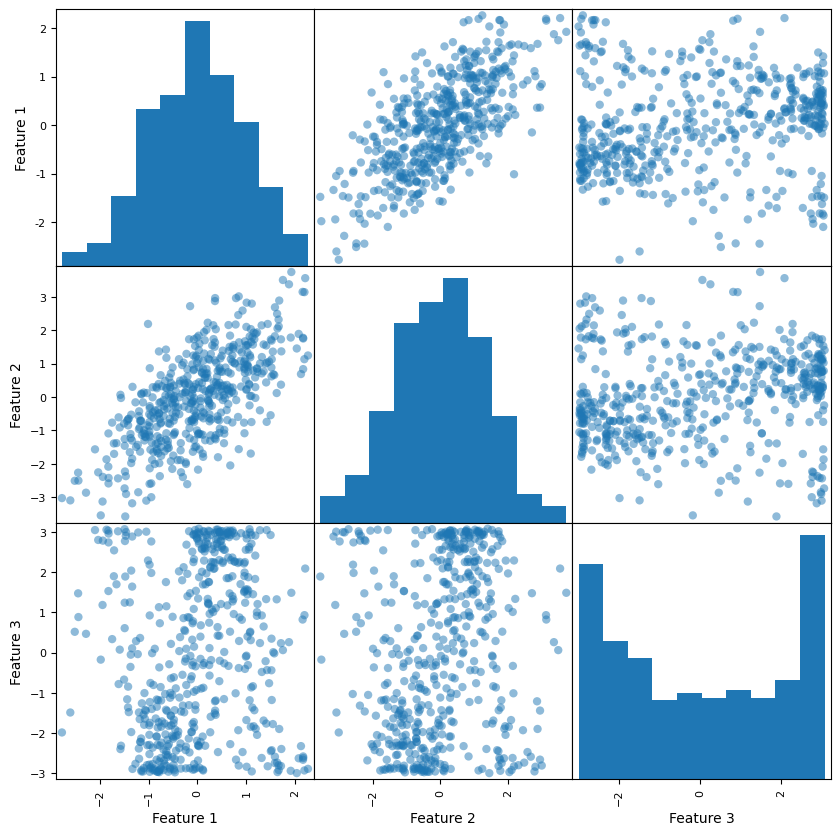

In [ ]:
df = pd.DataFrame(centered_data_2, columns=['Feature 1', 'Feature 2', 'Feature 3'])

pd.plotting.scatter_matrix(df, figsize=(10, 10), diagonal='hist', marker='o', grid=True)

plt.show()

*(b)* Determine the PCs and make the analogous scatter plot matrix for the 2d-coordinate systems spanned by the different pairs of PCs.

Eigenvalues: [0.38503192 2.24956199 4.4947884 ]
[4.4947884  2.24956199 0.38503192]
PC1: [0.12121678 0.1844957  0.9753296 ]
PC2: [ 0.51120047  0.83065188 -0.22066159]
PC3: [-0.85087048  0.52533684  0.00637466]


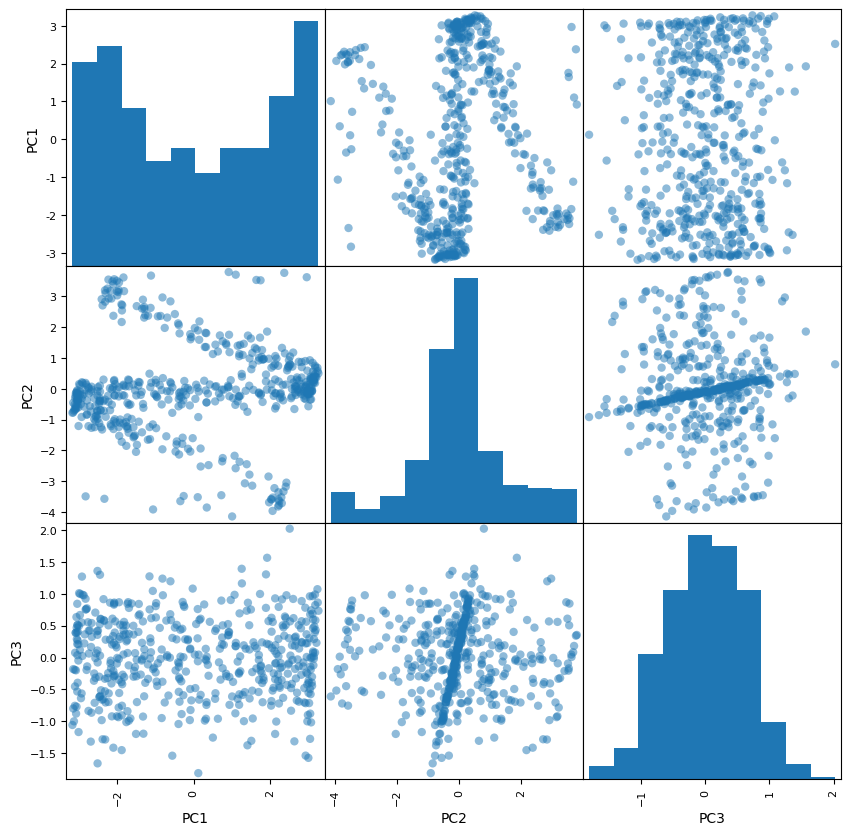

In [ ]:
cov_matrix_2 = np.cov(centered_data_2.T)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix_2)
print(f"Eigenvalues: {eigenvalues}")

idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
print(eigenvalues)
eigenvectors = eigenvectors[:, idx]

pc_1 = eigenvectors[:, 0]
pc_2 = eigenvectors[:, 1]
pc_3 = eigenvectors[:, 2]


print(f"PC1: {pc_1}")
print(f"PC2: {pc_2}")
print(f"PC3: {pc_3}")



projected_data = np.dot(centered_data_2, eigenvectors)
df = pd.DataFrame(projected_data, columns=['PC1', 'PC2', 'PC3'])

pd.plotting.scatter_matrix(df, figsize=(10, 10), diagonal='hist', marker='o', grid=True)

plt.show()

*(c)* Examine the 3d-reconstruction of the data in the original coordinate systems when using only (i) the first, (ii) the first two or (iii) all three PCs for reconstruction. Discuss how useful these principal directions are.

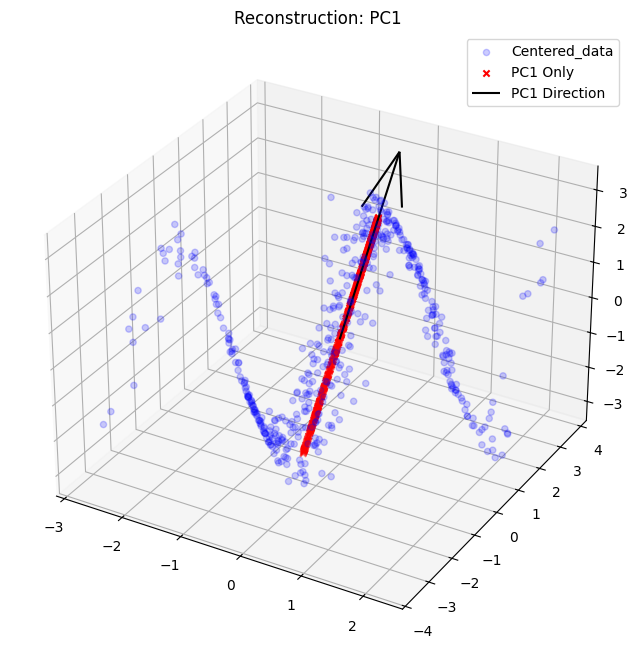

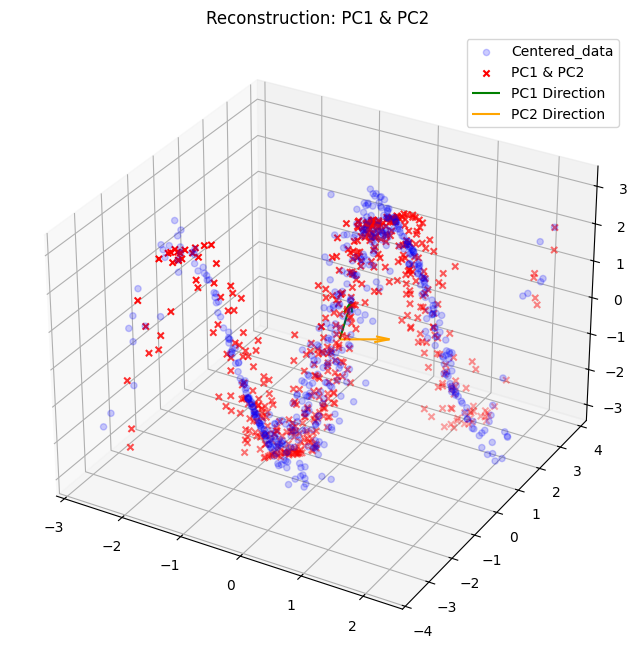

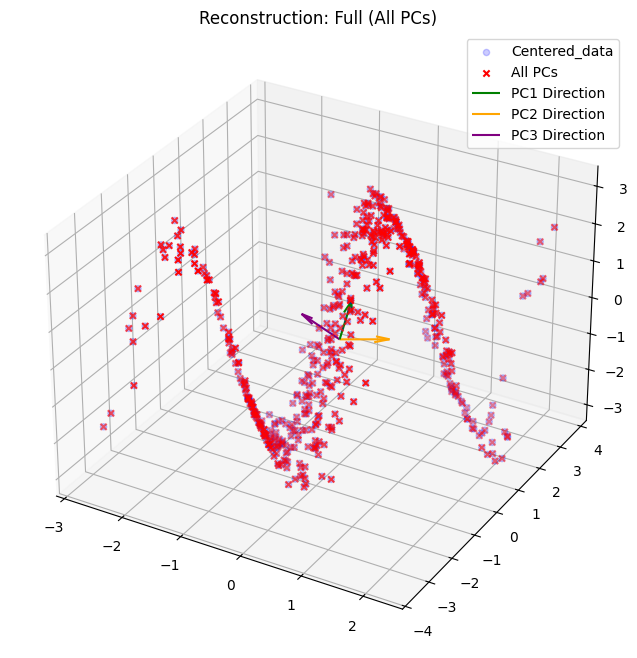

In [ ]:
recon_pc1 = projected_data.copy()
recon_first_two = projected_data.copy()
recon_all = projected_data.copy()

recon_pc1[:,1], recon_pc1[:,2] = 0, 0
recon_first_two[:,2] = 0

data_reconstructed_1 = recon_pc1 @ eigenvectors.T
data_reconstructed_2 = recon_first_two @ eigenvectors.T
data_reconstructed_3 = recon_all @ eigenvectors.T


fig1 = plt.figure(figsize=(8, 8))
ax1 = fig1.add_subplot(111, projection='3d')

ax1.scatter(centered_data_2[:, 0], centered_data_2[:, 1], centered_data_2[:, 2], c='blue', marker='o', alpha=0.2, label='Centered_data')
ax1.scatter(data_reconstructed_1[:, 0], data_reconstructed_1[:, 1], data_reconstructed_1[:, 2], c='red', marker='x', label='PC1 Only')
ax1.quiver(0, 0, 0, pc_1[0], pc_1[1], pc_1[2], color='black', length=5, alpha=1, normalize=True, label='PC1 Direction')

ax1.set_title('Reconstruction: PC1')
ax1.legend()
plt.show()

fig2 = plt.figure(figsize=(8, 8))
ax2 = fig2.add_subplot(111, projection='3d')

ax2.scatter(centered_data_2[:, 0], centered_data_2[:, 1], centered_data_2[:, 2], c='blue', marker='o', alpha=0.2, label='Centered_data')
ax2.scatter(data_reconstructed_2[:, 0], data_reconstructed_2[:, 1], data_reconstructed_2[:, 2], c='red', marker='x', label='PC1 & PC2')
ax2.quiver(0, 0, 0, pc_1[0], pc_1[1], pc_1[2], color='green', length=1, normalize=True, label='PC1 Direction')
ax2.quiver(0, 0, 0, pc_2[0], pc_2[1], pc_2[2], color='orange', length=1, normalize=True, label='PC2 Direction')

ax2.set_title('Reconstruction: PC1 & PC2')
ax2.legend()
plt.show()

fig3 = plt.figure(figsize=(8, 8))
ax3 = fig3.add_subplot(111, projection='3d')

ax3.scatter(centered_data_2[:, 0], centered_data_2[:, 1], centered_data_2[:, 2], c='blue', marker='o', alpha=0.2, label='Centered_data')
ax3.scatter(data_reconstructed_3[:, 0], data_reconstructed_3[:, 1], data_reconstructed_3[:, 2], c='red', marker='x', label='All PCs')
ax3.quiver(0, 0, 0, pc_1[0], pc_1[1], pc_1[2], color='green', length=1, normalize=True, label='PC1 Direction')
ax3.quiver(0, 0, 0, pc_2[0], pc_2[1], pc_2[2], color='orange', length=1, normalize=True, label='PC2 Direction')
ax3.quiver(0, 0, 0, pc_3[0], pc_3[1], pc_3[2], color='purple', length=1, normalize=True, label='PC3 Direction')

ax3.set_title('Reconstruction: Full (All PCs)')
ax3.legend()
plt.show()



Single PC Reconstruction: When using only the First PC, the reconstructed data lies on a straight line (the direction of the eigenvector with the largest eigenvalue). While this component identifies the direction of maximum variance, it fails to capture the non-linear "S-curve" geometry, proving that a 1D representation is insufficient.

Two-PC Reconstruction: Incorporating both PC1 and PC2 allows the reconstruction to almost perfectly preserve the "S-shape" of the data. This indicates that the dataset intrinsically lies on a 2D manifold embedded within 3D space Consequently, the first two PCs are sufficient to represent the data's core structure, enabling an effective dimensionality reduction from 3D to 2D with minimal information loss.


**Exercise H1.3: Projections of a dynamical system**

Using the data from the file expDat.txt, we can interpret the data as describing the process of a “large” system with N = 20 dimensions at each timepoint (cf. Exercise Sheet 00b).


*(a)* Find the 20 Principal Components of this dataset.

In [ ]:
data3 = pd.read_csv("/content/drive/MyDrive/MI2/Sheet01/expDat.txt")


#data3 = pd.read_csv("/content/expDat.txt", index_col=0)
#data3.head()

In [86]:
X = data3.to_numpy()
X = X[:,1:]  ##
X_centered = X - X.mean(axis=0)

In [87]:
cov_matrix_3 = np.cov(X_centered.T) # compute covariance between columns
eigenvalues3, eigenvectors3 = np.linalg.eig(cov_matrix_3)

In [88]:
idx3 = np.argsort(eigenvalues3)[::-1]
eigenvalues3 = eigenvalues3[idx3]
eigenvectors3 = eigenvectors3[:, idx3] # sorting according to importance

In [89]:
pcs3 = eigenvectors3
scores3 = X_centered @ pcs3

*(b)* Plot the temporal evolution of the system projected onto the first two PCs by making:

*(i)* a scatter plot of the 100 datapoints in the 2d-coordinate system spanned by the first
two PCs. Color each point by its time index.

*(ii)* a line/scatter plot of the 100 data point projections onto the first PC and onto the
second PC (i.e., two lines in one plot, one line for the projections along each PC and
where the x-axis shows the time index). Use the same color scale as before to indicate
the time index in order to highlight the (temporal) relationship in both plots.

In [90]:
time = np.arange(1, scores3.shape[0]+1)
pc1 = scores3[:, 0]
pc2 = scores3[:, 1]

Text(0, 0.5, 'PC2 projection')

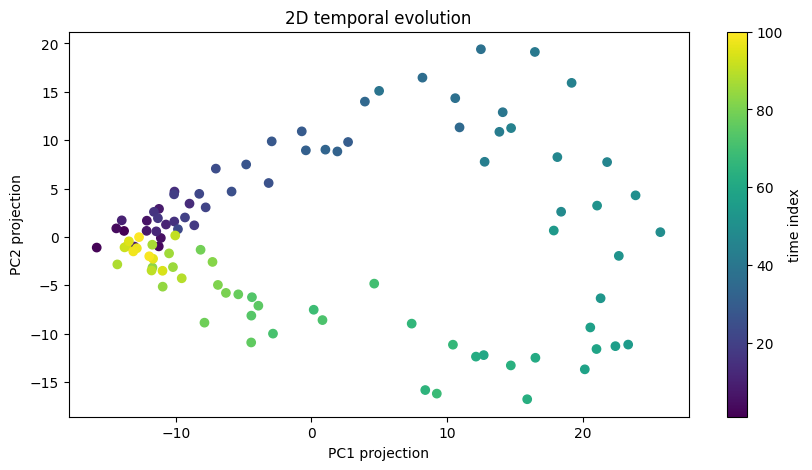

In [91]:
plt.figure(figsize=(10,5))
plt.scatter(pc1, pc2, c=time)
plt.colorbar(label="time index")
plt.title("2D temporal evolution")
plt.xlabel("PC1 projection")
plt.ylabel("PC2 projection")

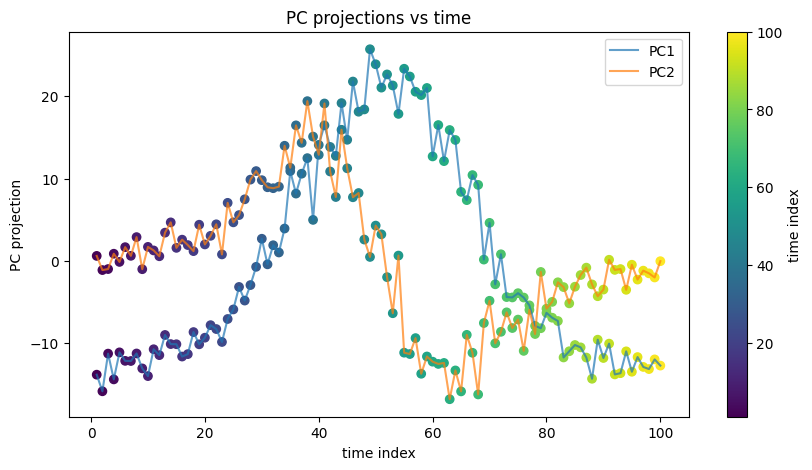

In [92]:
plt.figure(figsize=(10,5))
plt.plot(time, pc1, label="PC1", alpha=0.7)
plt.plot(time, pc2, label="PC2", alpha=0.7)
plt.scatter(time, pc1, c=time)
plt.scatter(time, pc2, c=time)
plt.colorbar(label="time index")
plt.title("PC projections vs time")
plt.xlabel("time index")
plt.ylabel("PC projection")
plt.legend()

*(c)* Create a new dataset by shuffling the data (i.e. reorder each of the 100 data point components in a different random sequence).

In [93]:
X_shuffled = X.copy()
print(X.shape)
for i in range (X.shape[1]): # loop over the 20 columns
  np.random.shuffle(X_shuffled[:, i]) # shuffle along rows

(100, 20)


*(d)* Plot the covariance matrices and scree plots for both the original and the scrambled data and
interpret your results.

Text(0.5, 1.0, 'Covariance matrix (shuffled)')

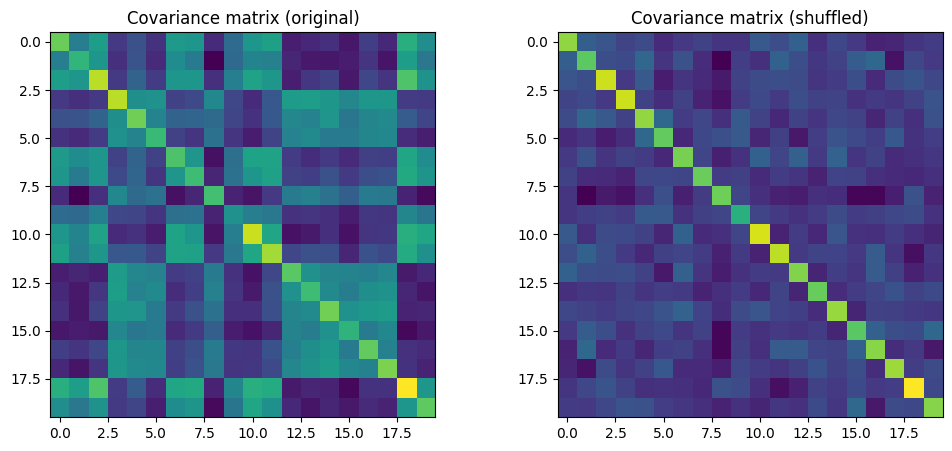

In [94]:
cov_matrix_3_shuffled = np.cov(X_shuffled, rowvar=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))
ax1.imshow(cov_matrix_3)
ax1.set_title("Covariance matrix (original)")
ax2.imshow(cov_matrix_3_shuffled)
ax2.set_title("Covariance matrix (shuffled)")

In [95]:
eigenvalues_shuffled, eigenvectors_shuffled = np.linalg.eig(cov_matrix_3_shuffled)

idx3s = np.argsort(eigenvalues_shuffled)[::-1]
eigenvalues_shuffled = eigenvalues_shuffled[idx3s]
eigenvectors_shuffled = eigenvectors_shuffled[:, idx3s]

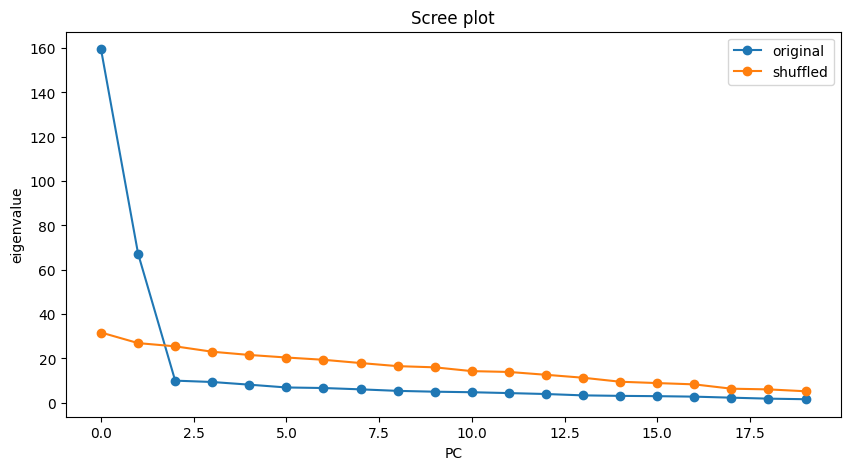

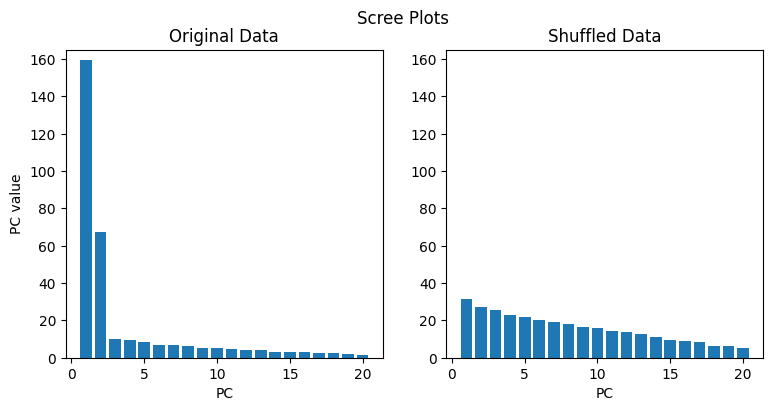

In [96]:
plt.figure(figsize=(10,5))
plt.plot(eigenvalues3, label="original", marker="o")
plt.plot(eigenvalues_shuffled, label="shuffled", marker="o")
plt.title("Scree plot")
plt.xlabel("PC")
plt.ylabel("eigenvalue")
plt.legend()

#Scree plots
fig, ax = plt.subplots(1,2,figsize=(9,4))

ax[0].bar(np.arange(1, 21), eigenvalues3)
ax[0].set_ylim(0, 165)
ax[0].set_xlabel("PC")
ax[0].set_ylabel("PC value")
ax[0].set_title("Original Data")
ax[1].bar(np.arange(1, 21), eigenvalues_shuffled)
ax[1].set_ylim(0, 165)
ax[1].set_xlabel("PC")
ax[1].set_title("Shuffled Data")
fig.suptitle("Scree Plots");

The steep decay in the scree plot of the original data indicates that most of the variance is captured by the first two principle components. The flatter scree plot for the shuffled data suggests that the variance is distributed more evenly across principle components, so it doesnot contain the meaningful low-dimensional structure of the original dataset.

*(e)* What would be the result if we use them same shuffling for all columns, i.e. randomizing
only the row order? You don’t need to program anything to answer this question.


In this case, the relationships between the variables persist, and only the time index is changed. Hence, the covariance matrix, principle components, and scree plots will not change.

**Exercise H1.4: Image data compression and reconstruction**

The file imgpca.zip contains training images from two different categories, namely nature and buildings. The prefix n is used for the nature images, while the prefix b is used for the images of buildings.

*(a)* For each category separately: Randomly sample at least p = 5000 patches (e.g. 500 per image) of 16 × 16 = 256 pixels from this set of images and assemble them in a 256 × p matrix.

In [ ]:
from PIL import Image
import glob
import os

def get_patches_exact(image_folder, prefix, p=5000, patch_size=16):
    search_path = os.path.join(image_folder, f"{prefix}*.jpg")
    image_files = glob.glob(search_path)
    num_images = len(image_files)

    if num_images == 0:
        return None

    all_patches = []
    base_patches_per_image = p // num_images
    extra_patches = p % num_images

    for idx, img_path in enumerate(image_files):
        img = Image.open(img_path).convert('L')
        img_array = np.array(img)
        h, w = img_array.shape

        n_to_take = base_patches_per_image + (1 if idx < extra_patches else 0)

        for _ in range(n_to_take):
            i = np.random.randint(0, h - patch_size)
            j = np.random.randint(0, w - patch_size)
            patch = img_array[i:i+patch_size, j:j+patch_size]
            all_patches.append(patch.flatten())

    return np.array(all_patches).T


folder_path = "/content/drive/MyDrive/MI2/Sheet01/imgpca"

nature_matrix = get_patches_exact(folder_path, "n")
building_matrix = get_patches_exact(folder_path, "b")

print(nature_matrix.shape)
print(building_matrix.shape)


(256, 5000)
(256, 5000)


*(b)* Calculate the PCs of these image patches and visualize the direction of the first 24 PCs as 16 × 16 images. Are there differences between the PC “images” of buildings vs. nature?

In [ ]:
cov_matrix_n = np.cov(nature_matrix)
eigenvalues_n, eigenvectors_n = np.linalg.eigh(cov_matrix_n)

idx = eigenvalues_n.argsort()[::-1]
eigenvalues_n = eigenvalues_n[idx]
eigenvectors_n = eigenvectors_n[:, idx]

cov_matrix_b = np.cov(building_matrix)
eigenvalues_b, eigenvectors_b = np.linalg.eigh(cov_matrix_b)

idx = eigenvalues_b.argsort()[::-1]
eigenvalues_b = eigenvalues_b[idx]
eigenvectors_b = eigenvectors_b[:, idx]

print(eigenvectors_b.shape)
print(eigenvectors_n.shape)


(256, 256)
(256, 256)


In [ ]:
def plot_eigenpatches(eigenvectors, title):
    plt.figure(figsize=(12, 8))
    plt.suptitle(title, fontsize=16)
    for i in range(24):
        plt.subplot(4, 6, i + 1)
        patch = eigenvectors[:, i].reshape(16, 16)
        plt.imshow(patch, cmap='gray')
        plt.axis('off')
        plt.title(f'PC {i+1}')
    plt.tight_layout()
    plt.show()

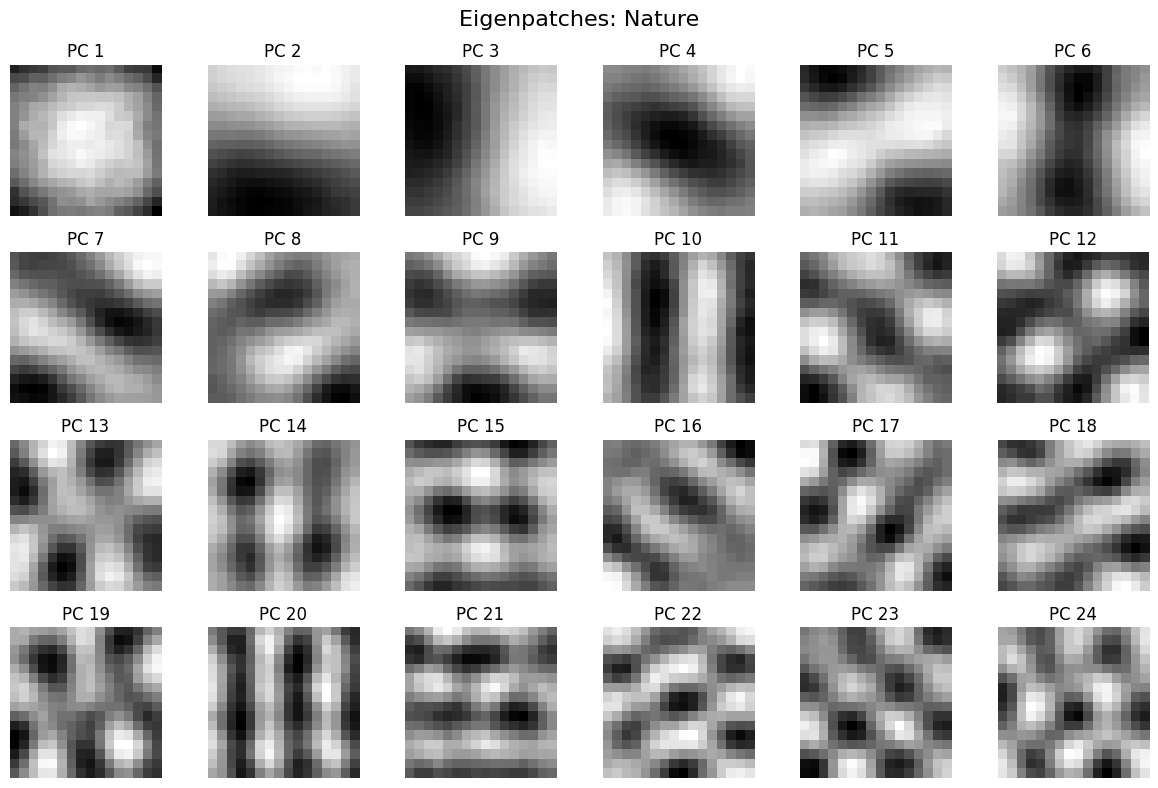

In [ ]:
plot_eigenpatches(eigenvectors_n, "Eigenpatches: Nature")


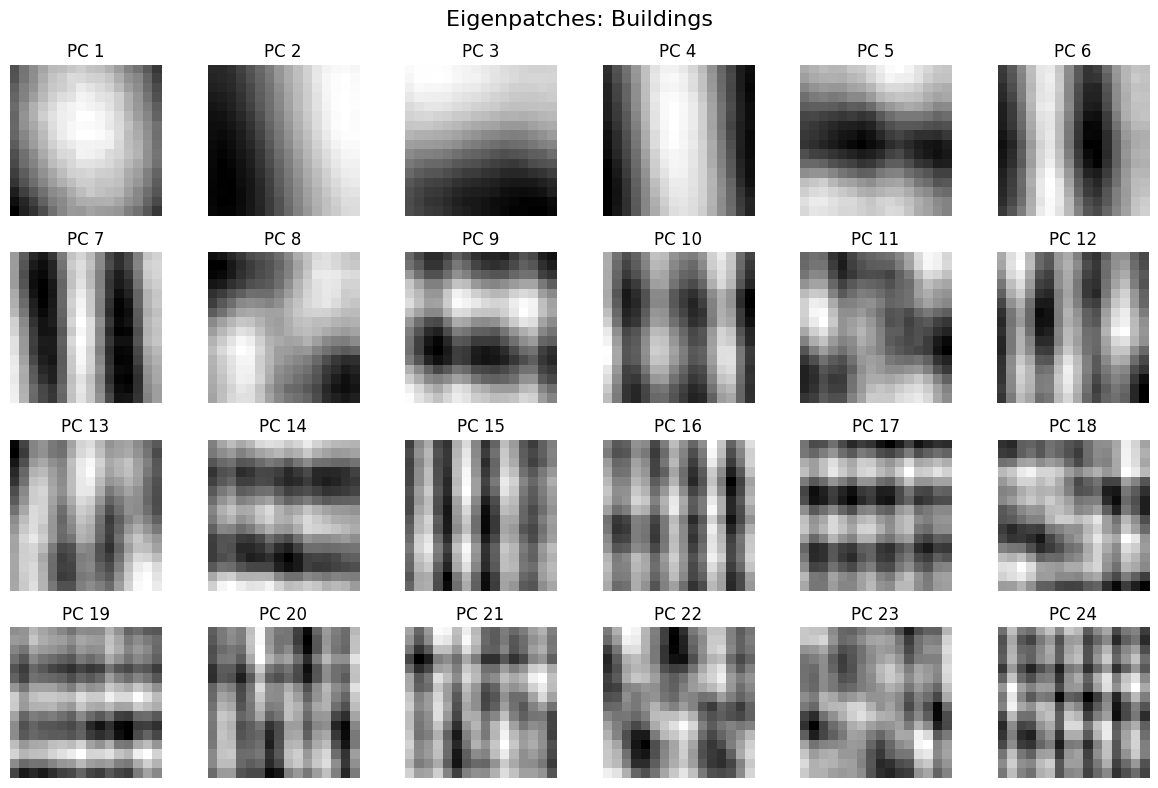

In [ ]:
plot_eigenpatches(eigenvectors_b, "Eigenpatches: Buildings")


*(c)* Answer using a scree plot: How many PCs should you keep for each of the two categories? What are the resulting respective compression ratios (qualitatively)?

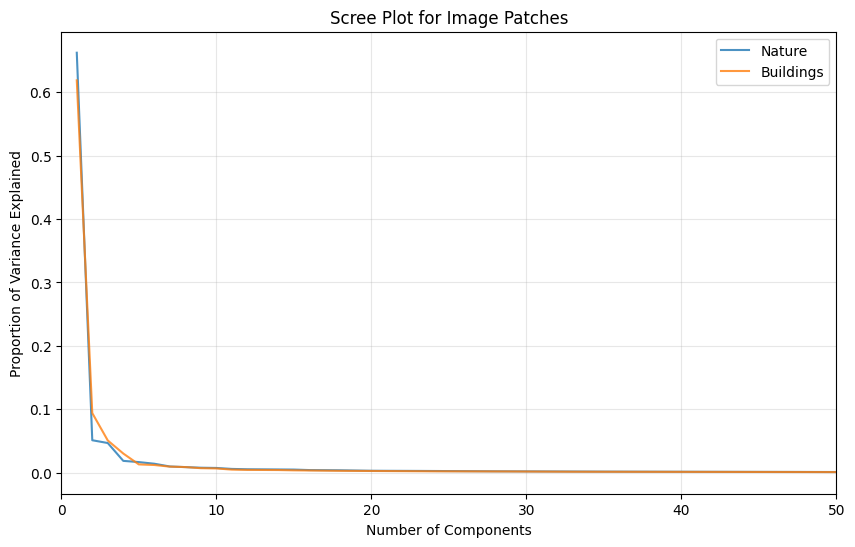

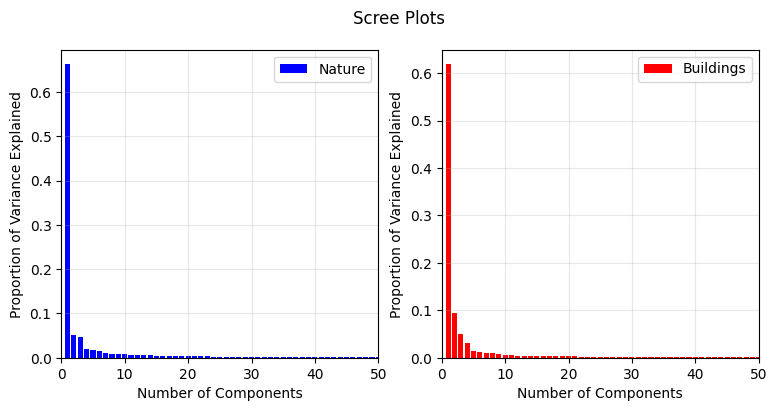

In [ ]:
var_nature = eigenvalues_n / np.sum(eigenvalues_n)
var_buildings = eigenvalues_b / np.sum(eigenvalues_b)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 257), var_nature, label='Nature', alpha=0.8)
plt.plot(range(1, 257), var_buildings, label='Buildings', alpha=0.8)
plt.xlabel('Number of Components')
plt.ylabel('Proportion of Variance Explained')
plt.title('Scree Plot for Image Patches')
plt.legend()

plt.xlim(0, 50)
plt.grid(True, alpha=0.3)
plt.show()


fig, ax = plt.subplots(1,2,figsize=(9,4))

ax[0].bar(range(1, 257), var_nature, label='Nature', color="blue")
ax[0].set_xlim(0, 50)
ax[0].set_xlabel("Number of Components")
ax[0].set_ylabel("Proportion of Variance Explained")
ax[0].legend()
ax[0].grid(True, alpha=0.3)
ax[1].bar(range(1, 257), var_buildings, label='Buildings', color="red")
ax[1].set_xlim(0, 50)
ax[1].set_xlabel("Number of Components")
ax[1].set_ylabel("Proportion of Variance Explained")
ax[1].legend()
ax[1].grid(True, alpha=0.3)
fig.suptitle("Scree Plots");





*(d)* Comparing image statistics: How similar are the statistics of nature vs building images? One way to go about this, is to reconstruct the projected image patches back into image space while alternating which basis we use for reconstruction.

 use the basis with which the patches were originally projected (i.e. using the

*   A. PCs that match the category of the image)
OR
*   B. reconstruct the patches using the “wrong” basis (i.e. the PCs of the other image category).




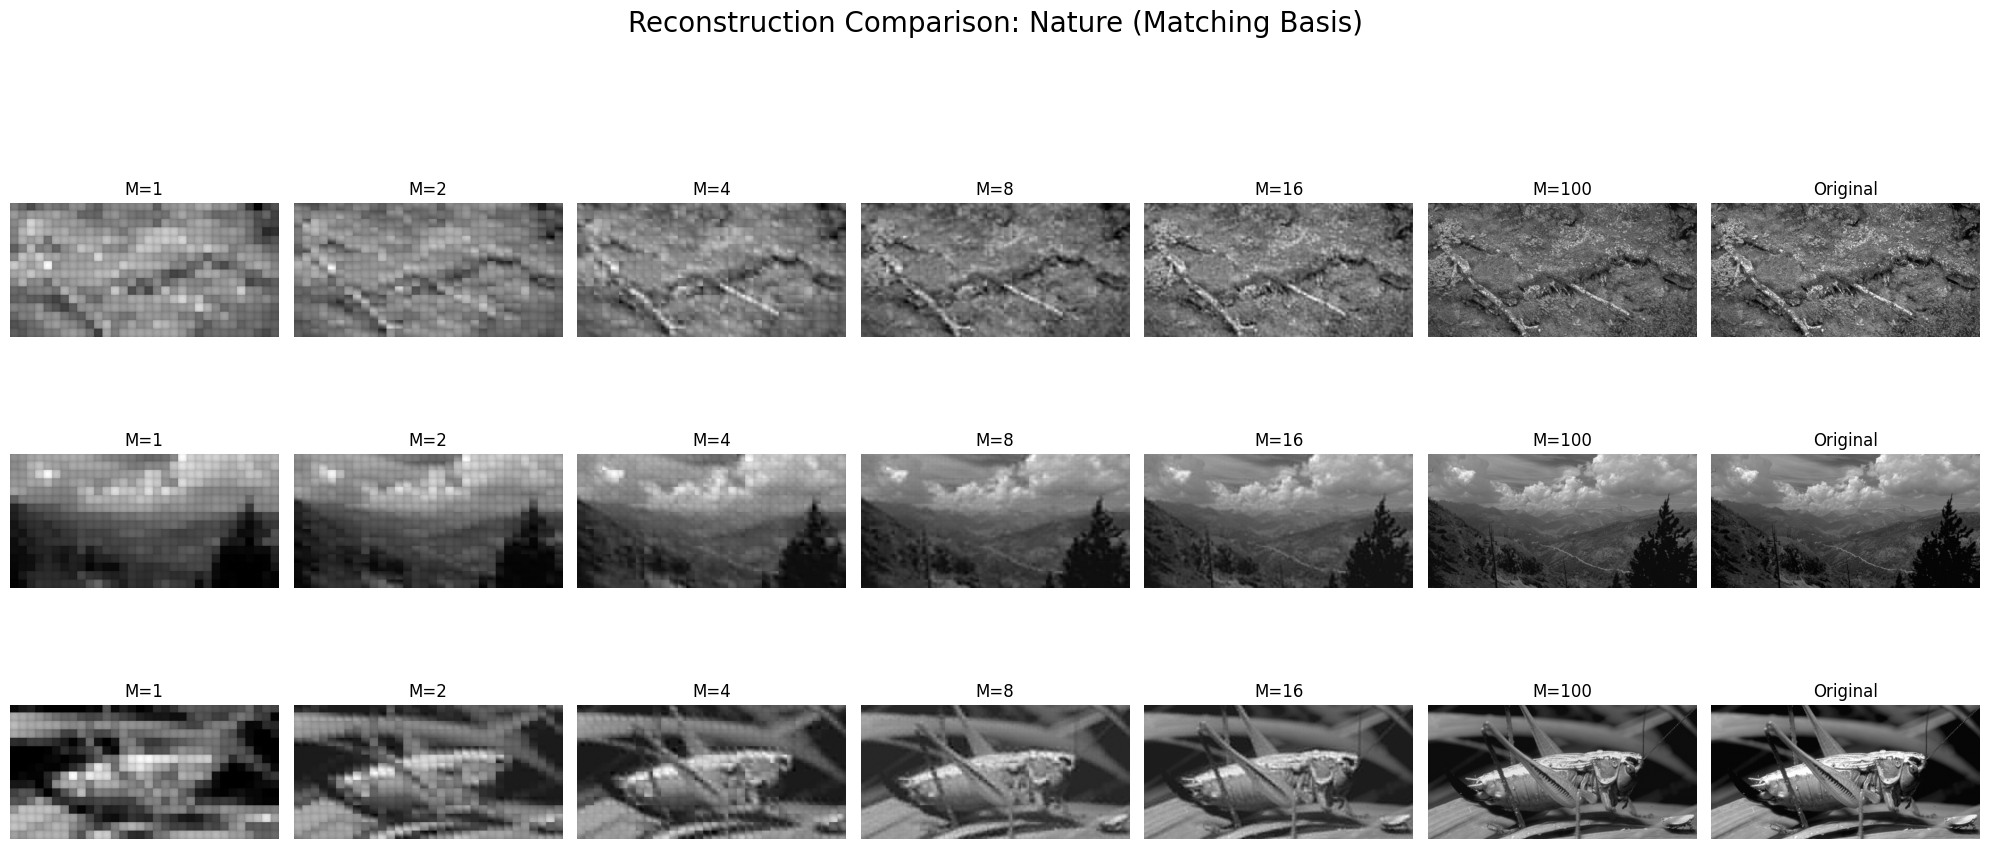

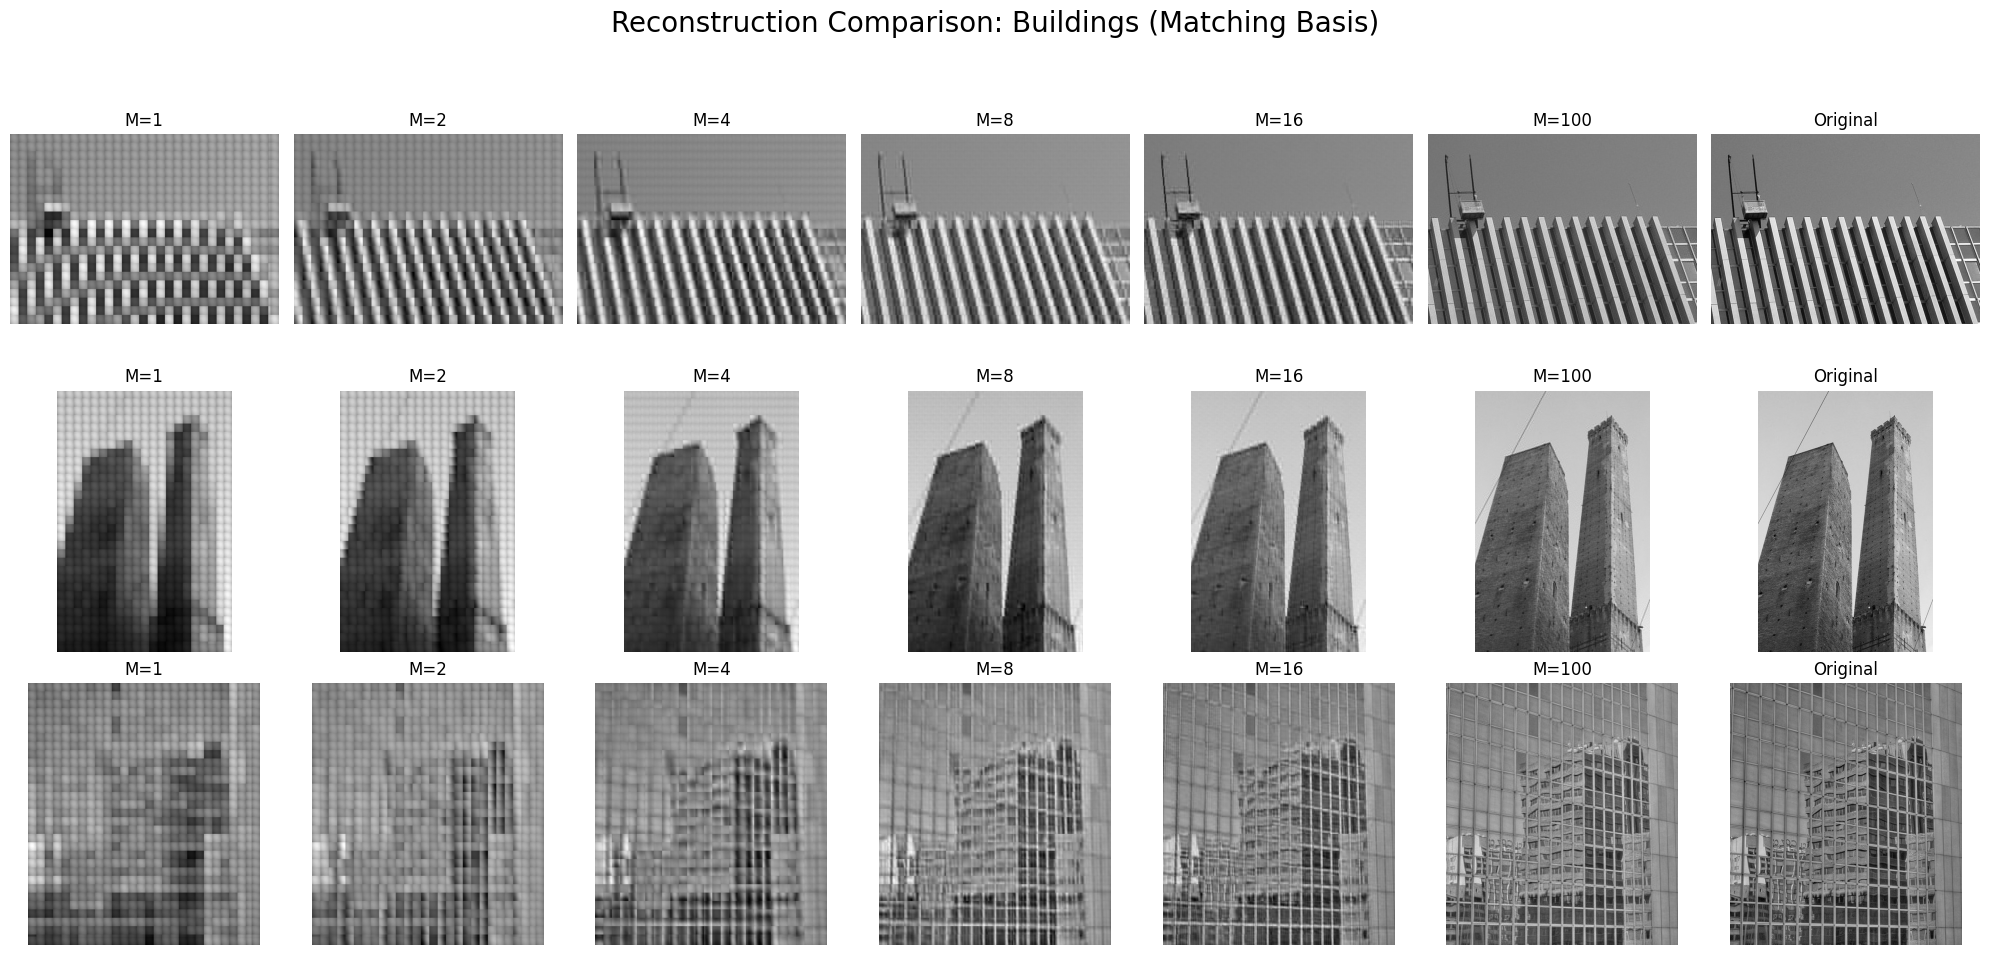

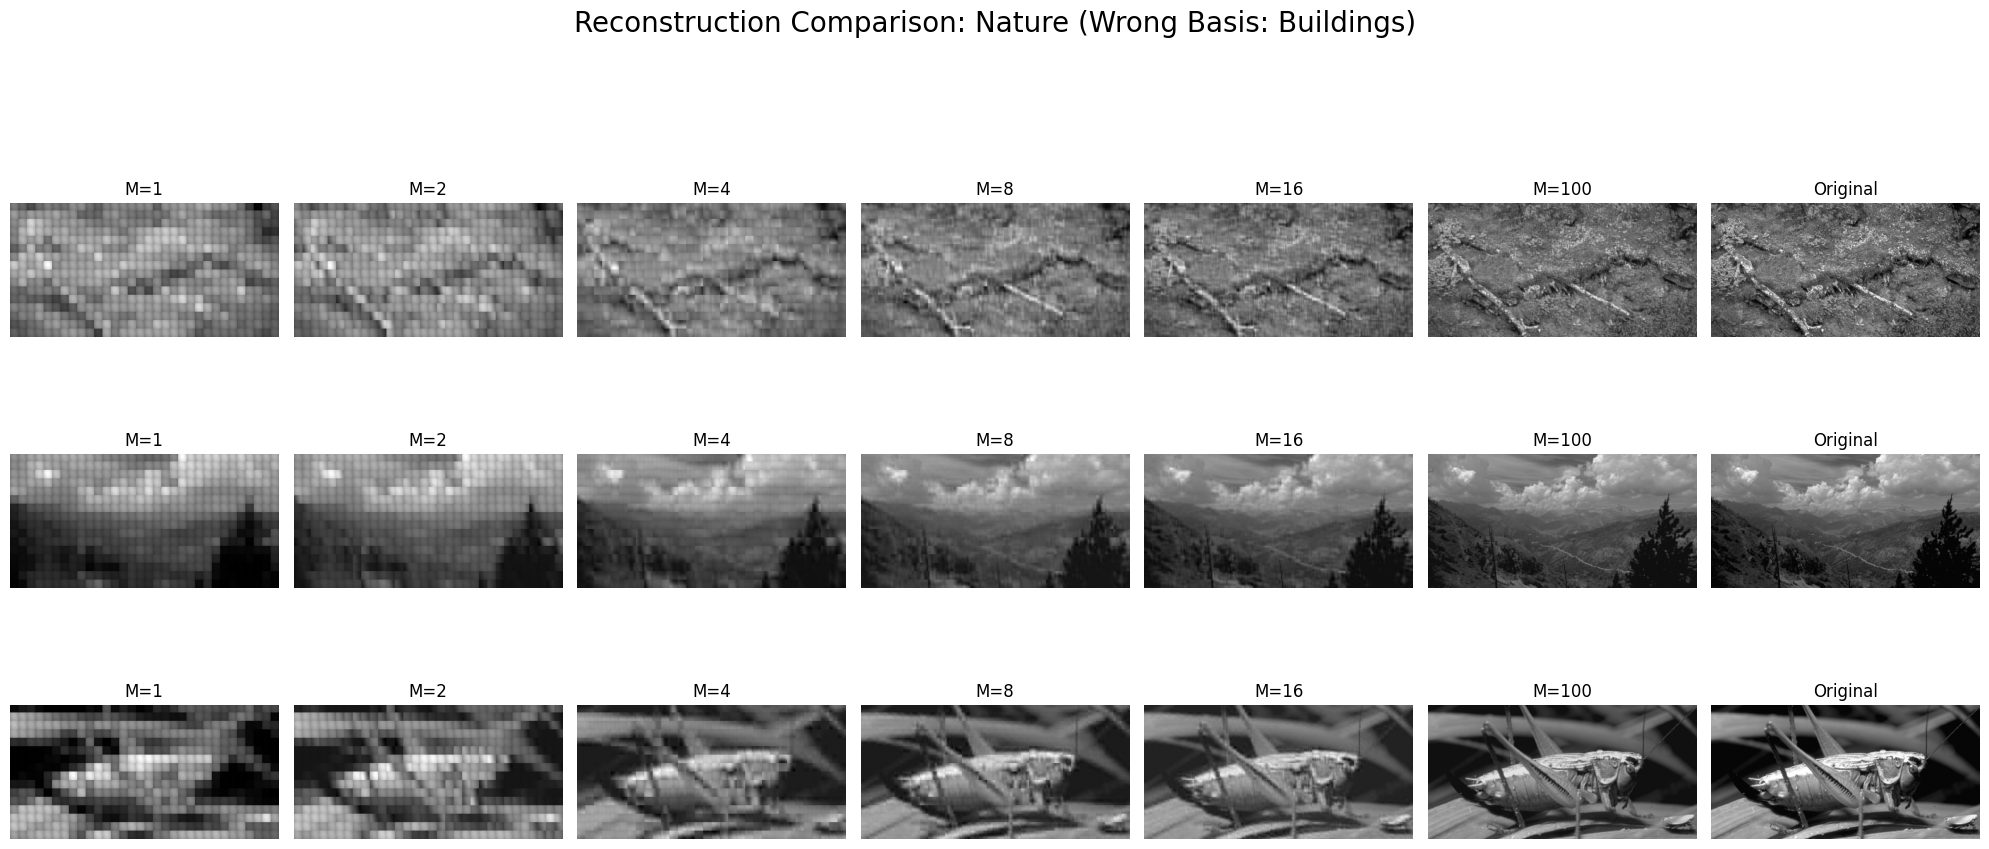

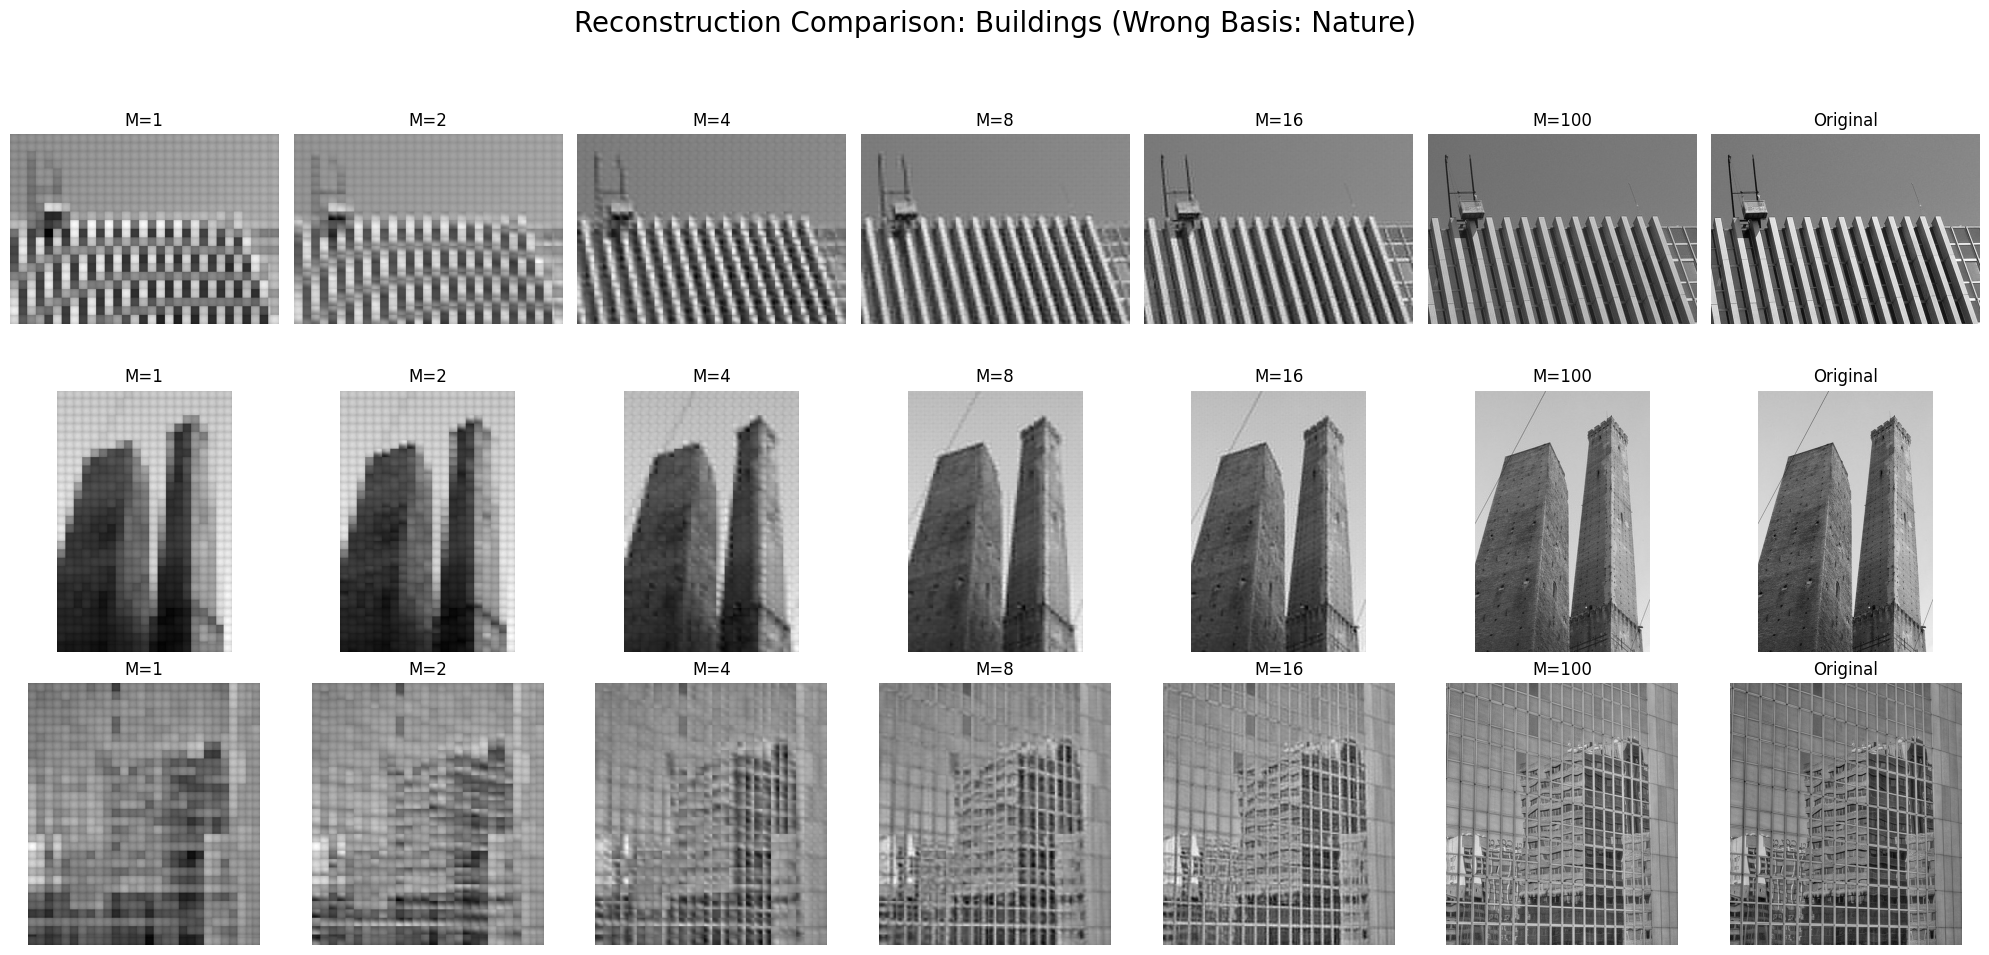

In [ ]:
# Manage and retrieve image files
def get_first_3_files(folder, prefix):
    search_path = os.path.join(folder, f"{prefix}*.jpg")
    files = glob.glob(search_path)
    return sorted(files)[:3]

# Extract files from the specified folder
nature_files = get_first_3_files(folder_path, 'n')
building_files = get_first_3_files(folder_path, 'b')

# Extract non-overlapping patches with boundary coverage (overlap at edges)
def get_image_patches(image_path):
    img = Image.open(image_path).convert('L')
    img_array = np.array(img, dtype=np.float32)
    h, w = img_array.shape

    patches = []
    # Create indices for 16x16 grids
    h_indices = list(range(0, h - 16, 16))
    w_indices = list(range(0, w - 16, 16))

    # Ensure full coverage by adding the last possible index (boundary regions)
    h_indices.append(h - 16)
    w_indices.append(w - 16)

    for i in h_indices:
        for j in w_indices:
            patch = img_array[i:i+16, j:j+16]
            patches.append(patch.flatten())

    return np.array(patches), (h, w), (h_indices, w_indices)

# Perform PCA Projection and Reconstruction
def project_and_reconstruct(flatten_patch, M, eigenvectors):
    # Project patches onto the first M principal components
    weights = np.dot(flatten_patch, eigenvectors[:, :M])
    # Reconstruct back to the original 256-dimensional space
    return np.dot(weights, eigenvectors[:, :M].T)

# Reassemble patches back into a full image
def reassemble_image(recon_patch, h, w, h_indices, w_indices):
    recon_img = np.zeros((h, w))
    patch_idx = 0
    for i in h_indices:
        for j in w_indices:
            # Reshape 256 vector back to 16x16 and place it in the image
            recon_img[i:i+16, j:j+16] = recon_patch[patch_idx].reshape(16, 16)
            patch_idx += 1
    return recon_img

# Main function to plot the 3x7 grid comparison
def plot_category_reconstruction(image_files, M_list, eigenvectors, category_name):
    fig, axes = plt.subplots(3, 7, figsize=(20, 10))
    fig.suptitle(f"Reconstruction Comparison: {category_name}", fontsize=20)

    for row_idx, img_path in enumerate(image_files):
        # Extract patches once per image
        patches_flat, (h, w), (h_indices, w_indices) = get_image_patches(img_path)

        for col_idx, m_val in enumerate(M_list):
            # Reconstruct and reassemble for each M value
            reco_flat = project_and_reconstruct(patches_flat, m_val, eigenvectors)
            final_image = reassemble_image(reco_flat, h, w, h_indices, w_indices)

            ax = axes[row_idx, col_idx]
            ax.imshow(final_image, cmap='gray')
            ax.set_title(f"M={m_val}")
            ax.axis('off')

        # Show the original image in the 7th column
        original_img = Image.open(img_path).convert('L')
        ax_orig = axes[row_idx, 6]
        ax_orig.imshow(original_img, cmap='gray')
        ax_orig.set_title("Original")
        ax_orig.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Execution
M = [1, 2, 4, 8, 16, 100]

# Generate Matching Basis plots
plot_category_reconstruction(nature_files, M, eigenvectors_n, "Nature (Matching Basis)")
plot_category_reconstruction(building_files, M, eigenvectors_b, "Buildings (Matching Basis)")

# Generate Wrong Basis plots (to answer the second part of question d)
plot_category_reconstruction(nature_files, M, eigenvectors_b, "Nature (Wrong Basis: Buildings)")
plot_category_reconstruction(building_files, M, eigenvectors_n, "Buildings (Wrong Basis: Nature)")